# Typed Judgments

**TypeSafe's System One model as a pipeline stage — assertion gating on extracted edges, adjudication of
the entity-resolution review band, and both carried into the graph as data.**

Every extractor in this repo is one of two shapes. GLiNER2.5 is a **span model**: it finds text and types
it, and everything it knows must be anchored in a span. The `claude` CLI is a **generative model**: it will
answer anything, in prose, and the work is constraining it back down to JSON. Both have a hole in the same
place — the small semantic judgments the pipeline needs *between* stages, which are neither spans nor
essays:

> is this extracted edge actually **asserted**, or hedged, denied, or conditional?
>
> are these two mentions the **same company**, or two companies with similar names?

[TypeSafe](https://docs.typesafe.ai) calls its model for this shape a **System One** model. You send
**state** — text, or a JSON object of named fields — and **typed questions**, and you get typed answers
with calibrated probabilities. Three question types, and that is the whole vocabulary:

| | asks | returns |
|---|---|---|
| **`Choice`** | which one of these options? | the label, `probabilities` over all labels, `confidence` |
| **`Noul`** | is this true? | a single probability of yes, 0–1 |
| **`Score`** | which level, on this described scale? | an expected position, `legend`, `probabilities`, `confidence` |

There is no text to parse and no schema to enforce, because **the answer set is the request**. That is a
different bargain from both other extractors, and it lands in the two places the pipeline explicitly leaves
open.

### Where it goes

| stage | the open question | what the repo does today | what this notebook does |
|---|---|---|---|
| **extract** | is this edge asserted or hedged? | GLiNER span-attribute pass, approximate | one `Choice` over four assertion statuses |
| **resolve** | are these two mentions the same entity? | `review_band()` — documented as *"the slot an LLM adjudicator fills"* | one `Score` over three levels + three diagnostic `Noul`s |
| **graph** | which judgments become properties? | confidence and support | assertion status, per edge, filterable without re-running inference |

`src/kgx/typesafe.py` is the adapter: a disk-cached client with the same contract as `kgx.llm.ClaudeCLI`,
plus `judge_edges`, `adjudicate_pairs` and `apply_verdicts`.

### One break with the rest of the repo

**This notebook needs an API key.** `TYPESAFE_API_KEY`, from
[console.typesafe.ai](https://console.typesafe.ai/). Notebooks 01–02 and 08–09 need nothing; 03, 05, 06 and
07 need the `claude` CLI. This one needs a hosted API, and there is no local fallback and no stub — a stub
would make every measurement below meaningless.

What softens it is the same thing that softens the `claude` dependency: **every response is cached to disk**,
content-addressed on `(model, state, questions)`. A cache hit reconstructs a real `SystemOneResponse`, so
replayed and live code are the same code. A second run is free, byte-identical, and needs no key at all.

## 0. Setup

In [1]:
import os, sys, time, json, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import msgspec
import pandas as pd
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 44)

import kgx
from kgx.evaluate import score_triples, graph_triples, comparison_table, MatchPolicy
from kgx.data.documents import DOCUMENTS, ALIAS_GROUPS, MODALITY_TRAPS, GOLD_DOC_FACTS

import kgx.typesafe as kts     # NOT exported from `kgx` -- importing it is a deliberate act

MATCH = MatchPolicy(normalize_names=True, use_aliases=True)

print(f"corpus   {len(DOCUMENTS)} documents, "
      f"{sum(len(d['text'].split()) for d in DOCUMENTS)} words")
print(f"gold     {len(GOLD_DOC_FACTS)} triples, {len(ALIAS_GROUPS)} alias groups, "
      f"{len(MODALITY_TRAPS)} modality traps")
print(f"matching {MATCH.label}")

corpus   10 documents, 2284 words
gold     47 triples, 13 alias groups, 11 modality traps
matching normalised + aliases


In [2]:
import typesafe_sdk

ts = kts.CachedTypeSafe(cache_dir=ROOT / "output" / "typesafe_cache")
print("typesafe-sdk", typesafe_sdk.__version__)
print(ts)

if ts.available:
    print("models:", ", ".join(ts.check()))
else:
    print("\nTYPESAFE_API_KEY is not set -- cached responses will replay, new ones will raise.")
    print(f"cached responses on disk: {len(list(ts.cache_dir.glob('*.json')))}")

typesafe-sdk 0.6.0
CachedTypeSafe(model='jev-latest', cache_dir='/Users/lyonwj/github/johnymontana/extraction-sandbox/output/typesafe_cache', key=unset)

TYPESAFE_API_KEY is not set -- cached responses will replay, new ones will raise.
cached responses on disk: 98


---

## 1. What one request looks like

Three question types, one state, one request. Everything else in this notebook is this call with more
questions.

The state is a **JSON object with named fields**, not a blob — the docs are explicit that this is the
default choice, because each part of the context keeps a name the instructions can point at with a
backticked path. `Does \`ticket.messages[0].text\` request a refund?` is a question the model can key on;
"does the text request a refund" attached to three concatenated paragraphs is not.

In [3]:
from typesafe_sdk import Choice, Noul, Score

demo_doc = DOCUMENTS[0]
probe = ts.ask(
    {"headline": demo_doc["title"], "body": demo_doc["text"][:900], "source": demo_doc["source"]},
    {
        "primary_event": Choice(
            instructions="What is the main corporate event `body` reports?",
            criteria={
                "acquisition":   "One company is buying another, or part of another.",
                "earnings":      "Results, guidance, or a financial report.",
                "litigation":    "A lawsuit, investigation, or enforcement action.",
                "partnership":   "An alliance, joint venture, or supply agreement.",
                "other":         "None of the above.",
            },
        ),
        "names_a_price": Noul(
            instructions="Does `body` state a transaction price or per-share consideration?",
        ),
        "certainty": Score(
            instructions="How settled is the main event `body` reports?",
            criteria=[
                "Speculative -- rumoured, or attributed to unnamed sources.",
                "Announced but conditional -- agreed, pending approval or closing.",
                "Completed -- it has happened.",
            ],
        ),
    },
)

choice, noul, score = probe.choices["primary_event"], probe.nouls["names_a_price"], probe.scores["certainty"]
print(f"{demo_doc['title']}\n")
print(f"primary_event   {choice.choice!r}  confidence {choice.confidence:.3f}")
print("                " + "  ".join(f"{k}={v:.3f}" for k, v in
                                     sorted(choice.probabilities.items(), key=lambda kv: -kv[1])))
print(f"names_a_price   {noul.noul:.3f}")
print(f"certainty       {score.score:.3f}  confidence {score.confidence:.3f}")
for level, p in sorted(score.probabilities.items()):
    print(f"                {level}  {p:.3f}  {score.legend[level]}")
print(f"\nusage           {probe.usage.input_tokens} in / {probe.usage.output_tokens} out"
      f"   ({'replayed' if ts.n_cached else 'live'})")

Northwind Logistics to Acquire Cascade Freight Systems in $1.4 Billion Transaction

primary_event   'acquisition'  confidence 1.000
                acquisition=1.000  other=0.000  partnership=0.000  litigation=0.000  earnings=0.000
names_a_price   0.990
certainty       1.000  confidence 1.000
                0  0.000  Speculative -- rumoured, or attributed to unnamed sources.
                1  1.000  Announced but conditional -- agreed, pending approval or closing.
                2  0.000  Completed -- it has happened.

usage           723 in / 97 out   (replayed)


Three things to notice, because they set up everything below.

**The `Choice` returns a distribution, not a label.** `confidence` summarises how concentrated that
distribution is — and the docs are careful that it means *concentration*, not correctness and not
permission to act. Two genuinely acceptable options split the mass and drag confidence down without
anything being wrong.

**The `Noul` is one number.** There is no separate confidence, because a probability of yes already carries
it. 0.5 means *equally likely yes or no*, not *medium*. That distinction is why a yes/no question and a
graded question are different primitives rather than one with a flag.

**The `Score` returns an expected level and the rubric it used.** The value falls between the integer
levels, so a 1.4 is a real answer — "announced, leaning conditional" — and not a rounding artefact. The
`legend` comes back with it, which is what lets a stored score be re-read months later.

---

## 2. Extraction — the judgment a span model cannot make

### 2.1 The baseline, unchanged

GLiNER2.5 over the ten `BUSINESS_NEWS` documents, exactly as notebook 01 runs it. Joint decoding, typed
endpoints enforced during decoding, no LLM.

In [4]:
t0 = time.perf_counter()
extractor = kgx.GlinerExtractor()
graphs = extractor.extract_batch(DOCUMENTS, kgx.BUSINESS_NEWS)
gliner_s = time.perf_counter() - t0

mentions = [m for g in graphs for m in g.mentions]
edges = [e for g in graphs for e in g.edges]
print(f"{len(mentions)} mentions, {len(edges)} edges from {len(graphs)} documents in {gliner_s:.1f}s")
print(f"ontology violations: {sum(len(g.validate(kgx.BUSINESS_NEWS)) for g in graphs)}")
print(f"infeasible documents: {sum(1 for g in graphs if not g.feasible)}")

display(pd.DataFrame([{"doc_id": g.doc_id, "words": len(g.text.split()),
                       "mentions": len(g.mentions), "edges": len(g.edges)} for g in graphs])
        .set_index("doc_id").T)

214 mentions, 170 edges from 10 documents in 13.0s
ontology violations: 0
infeasible documents: 0


doc_id,d01,d02,d03,d04,d05,d06,d07,d08,d09,d10
words,229,225,215,339,208,218,207,200,211,232
mentions,22,19,15,23,22,26,16,25,22,24
edges,35,8,5,17,22,15,12,37,10,9


### 2.2 The modality traps, asked directly

`kgx.data.documents.MODALITY_TRAPS` is eleven sentences planted in the corpus that have the **surface shape
of an asserted fact and are not one** — conditionals, denials, forecasts, a counterfactual, and one claim
attributed to an unnamed analyst. A pipeline with no modality pass asserts all eleven.

Before gating any edges, ask about the sentences on their own. State is the sentence; two questions, one
`Choice` over four statuses and one `Noul` that collapses them to the thing the graph actually needs.

**What is scored here and what is not.** Every one of the eleven is non-factual — that is why it is in the
list — so the `factual` Noul has a ground truth and is scored against it. The four-way status is *reported*
and not scored: the corpus's own `why` notes call several of these mixed ("negated expectation followed by a
hedged conditional reversal"), so there is no single gold label among my four to score them against.
Inventing one would be grading the model against my labelling, not against the corpus.

In [5]:
trap_rows = kts.judge_sentences(ts, [t["sentence"] for t in MODALITY_TRAPS])

traps = pd.DataFrame([
    {"doc": t["doc_id"],
     "sentence": t["sentence"][:78] + "…",
     "status": r["status"],
     "conf": round(r["status_conf"], 3),
     "factual": round(r["factual"], 3),
     "caught": r["factual"] < 0.5,
     "why (corpus)": t["why"][:46]}
    for t, r in zip(MODALITY_TRAPS, trap_rows)
])
display(traps)

caught = int(traps["caught"].sum())
print(f"caught {caught}/{len(traps)} planted traps  (factual < 0.5)")
print(f"mean factual probability: {traps['factual'].mean():.3f}   "
      f"max: {traps['factual'].max():.3f}")
print("\nstatus distribution:")
print(traps["status"].value_counts().to_string())

,doc,sentence,status,conf,factual,caught,why (corpus)
0,d01,"The proposed acquisition, if approved by...",hypothetical,1.00,0.02,True,hypothetical - conditional on regulatory...
1,d01,The Company does not expect to acquire a...,negated,0.84,0.20,True,negated expectation - no acquisition rel...
2,d02,Management has no plans to divest the Ca...,negated,0.93,0.66,False,negated intent - a divestiture is denied...
3,d03,We may face supply disruptions if tariff...,hypothetical,0.99,0.06,True,"mixed - the supplies(Torrent, Northwind)..."
4,d03,Should demand for expedited freight soft...,hypothetical,1.00,0.02,True,hypothetical - inverted conditional; no ...
5,d04,If tariffs on Asian-fabricated controlle...,hypothetical,1.00,0.03,True,counterfactual conditional - tariffs hav...
6,d05,The company said it has no plans to dive...,negated,0.86,0.71,False,"negated intent, reported speech - denies..."
7,d06,Duarte has acknowledged that the chipmak...,hypothetical,0.55,0.74,False,hypothetical plus explicit negation - no...
8,d07,The Company does not expect the SEC inqu...,negated,0.43,0.20,True,negated expectation followed by a hedged...
9,d09,One noted that if diesel remains above $...,hypothetical,1.00,0.05,True,"hypothetical, attributed to an unnamed a..."


caught 8/11 planted traps  (factual < 0.5)
mean factual probability: 0.266   max: 0.740

status distribution:
status
hypothetical    6
negated         5


A control matters here: a detector that answers "not factual" to everything scores 11/11 on a list of
eleven traps. So ask the same two questions about sentences from the same corpus that **are** plain
assertions, and check the two distributions actually separate.

In [6]:
CONTROLS = [
    "Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a "
    "definitive agreement to acquire Cascade Freight Systems for $1.4 billion in cash and stock.",
    "Cascade Freight Systems operates 41 cross-dock terminals across the Pacific Northwest "
    "and reported revenue of $612 million in fiscal 2025.",
    "Priya Raman is Chief Executive Officer of Northwind Logistics.",
    "A single vendor, Torrent Microsystems, supplies the controller boards used in "
    "substantially all of our telematics hardware.",
    "Halcyon Semiconductor Corporation operates fabrication sites in Phoenix, Dresden and Penang.",
]
control_rows = kts.judge_sentences(ts, CONTROLS)

controls = pd.DataFrame([
    {"sentence": s[:78] + "…", "status": r["status"],
     "conf": round(r["status_conf"], 3), "factual": round(r["factual"], 3),
     "asserted": r["factual"] >= 0.5}
    for s, r in zip(CONTROLS, control_rows)
])
display(controls)

print(f"traps    mean factual {traps['factual'].mean():.3f}  "
      f"range [{traps['factual'].min():.3f}, {traps['factual'].max():.3f}]")
print(f"controls mean factual {controls['factual'].mean():.3f}  "
      f"range [{controls['factual'].min():.3f}, {controls['factual'].max():.3f}]")
print(f"separated: {controls['factual'].min() > traps['factual'].max()}")

,sentence,status,conf,factual,asserted
0,Northwind Logistics Inc. (NASDAQ: NWL) t...,asserted,0.99,0.89,True
1,Cascade Freight Systems operates 41 cros...,asserted,1.00,0.81,True
2,Priya Raman is Chief Executive Officer o...,asserted,1.00,0.83,True
3,"A single vendor, Torrent Microsystems, s...",asserted,1.00,0.93,True
4,Halcyon Semiconductor Corporation operat...,asserted,1.00,0.83,True


traps    mean factual 0.266  range [0.020, 0.740]
controls mean factual 0.858  range [0.810, 0.930]
separated: True


Now look at the traps the `factual` Noul missed, against what the `Choice` said about the same sentence.

In [7]:
missed = traps[~traps["caught"]]
display(missed[["doc", "sentence", "status", "conf", "factual", "why (corpus)"]])

print("on the sentences the Noul let through, the Choice still called them:")
print(missed["status"].value_counts().to_string())
print(f"\nmean Choice confidence on those: {missed['conf'].mean():.2f}")

,doc,sentence,status,conf,factual,why (corpus)
2,d02,Management has no plans to divest the Ca...,negated,0.93,0.66,negated intent - a divestiture is denied...
6,d05,The company said it has no plans to dive...,negated,0.86,0.71,"negated intent, reported speech - denies..."
7,d06,Duarte has acknowledged that the chipmak...,hypothetical,0.55,0.74,hypothetical plus explicit negation - no...


on the sentences the Noul let through, the Choice still called them:
status
negated         2
hypothetical    1

mean Choice confidence on those: 0.78


**The two questions disagree, and the `Choice` is right.** Every sentence the `factual` Noul let through is
one the `Choice` labelled `negated` or `hypothetical` — and looking at them, the Noul is not wrong so much
as answering a question I asked badly:

> *"Management has no plans to divest the Cascade brand."*

Can that be recorded as a fact that currently holds? **Yes.** It is a true statement about management's
plans. The claim I wanted judged was the divestiture; the claim the model judged was the sentence. For a
denial those are opposite polarities, and the instruction did not say which one to take.

The `Choice` does not have this problem, because naming `negated` as a distinct outcome forces the
distinction the Noul collapses. That is the concrete version of the advice in the
[primitives guide](https://docs.typesafe.ai/primitives.md) — a Noul near 0.5 means *equally likely yes or
no*, not *partly*, so a question with a hidden second reading resolves to one of them rather than to the
middle. **Keep the distinction in the answer type; do not fold it into a probability and hope.**

It also says something about what the edge gate should trust, which §2.3 acts on: `supported` answers a
question with one reading (*does the document connect these two things*), and `status` carries the polarity.

### 2.3 Gating the extracted edges

The traps are a diagnostic on hand-picked sentences. The pipeline question is different: of the **170 edges
GLiNER actually decoded**, which are asserted?

Two questions per edge, and they are deliberately not one question:

- **`supported`** (`Noul`) — does the document connect these two things *at all*, in any modality? This
  catches extraction errors: an edge between two entities the document never relates.
- **`status`** (`Choice`) — how does the document present the claim? This catches the modality traps: an
  edge the document really does discuss, and denies.

An edge that fails the first is a *different error* from one that fails the second, and one question cannot
tell them apart.

**The batching is the interesting part.** All questions in a request share one state and are evaluated in
parallel, and extra questions cost only their own tokens. So the unit of work is one request per
**document** carrying two questions per candidate edge — not one request per edge. The alternative pays the
document's tokens once per edge instead of once per chunk.

In [8]:
def show_questions(questions):
    print(json.dumps(json.loads(msgspec.json.encode(questions)), indent=2))

print("the two questions asked about one edge:\n")
show_questions(kts.edge_questions(
    "Northwind Logistics", "acquires", "Cascade Freight Systems",
    relation_description=kgx.BUSINESS_NEWS.relation("acquires").description))

the two questions asked about one edge:

{
  "supported": {
    "type": "noul",
    "instructions": "Does the document say anything that bears on this claim: \u201cNorthwind Logistics\u201d \u2014 acquires \u2192 \u201cCascade Freight Systems\u201d? Here, \u201cacquires\u201d means: The head company is buying or has bought the tail. Answer yes if the document discusses this relationship at all, in any modality \u2014 asserted, denied, proposed or merely possible. Answer no if the document does not connect these two things.",
    "criteria": {
      "true": "The document addresses this relationship between these two specific things.",
      "false": "The document does not connect these two things, or one of them does not appear in it."
    }
  },
  "status": {
    "type": "choice",
    "criteria": {
      "asserted": "The text states this relationship as a present or past fact. It holds, or it held.",
      "hypothetical": "The text raises this relationship only as a possibility, a cond

In [9]:
t0 = time.perf_counter()
judgments = kts.judge_edges(ts, graphs, kgx.BUSINESS_NEWS, max_questions=24)
judge_s = time.perf_counter() - t0

J = pd.DataFrame([j.as_record() for j in judgments])
print(f"{len(J)} edges judged in {judge_s:.1f}s")
print(f"requests: {ts.n_calls} live, {ts.n_cached} replayed   "
      f"({ts.n_questions / max(1, ts.n_calls + ts.n_cached):.0f} questions per request)\n")
print(J["status"].value_counts().to_string())
print(f"\nkept (supported >= 0.5 and status == 'asserted'): {int(J['keep'].sum())} / {len(J)}")
display(J.sort_values("supported").head(12))

170 edges judged in 0.0s
requests: 0 live, 35 replayed   (11 questions per request)

status
asserted           120
negated             22
hypothetical        20
forward_looking      8

kept (supported >= 0.5 and status == 'asserted'): 114 / 170


,doc_id,head,relation,tail,gliner,supported,status,status_conf,keep
114,d08,Vantage Energy Partners,competes_with,Halcyon Semiconductor,0.311,0.07,negated,0.74,False
64,d04,Torrent Microsystems,subsidiary_of,Northwind Logistics,0.695,0.12,negated,0.66,False
169,d10,Northwind Logistics,subsidiary_of,Halcyon,0.873,0.13,negated,0.64,False
125,d08,Northwind Logistics,operates_in,Arizona,0.534,0.13,negated,0.20,False
50,d04,Northwind,acquires,Halcyon Semiconductor Corporation,0.702,0.14,negated,0.78,False
48,d04,Northwind Logistics,acquires,Halcyon Semiconductor Corporation,0.820,0.19,negated,0.81,False
122,d08,Northwind Logistics,operates_in,Arizona,0.518,0.23,negated,0.21,False
108,d07,Northwind Logistics Inc.,partners_with,SEC,0.744,0.27,negated,0.63,False
107,d07,Northwind Logistics Inc.,partners_with,SEC,0.903,0.28,negated,0.59,False
3,d01,Cascade Freight Systems,competes_with,Northwind Logistics,0.531,0.29,negated,0.54,False


The edges the gate drops, and why — the two failure modes side by side.

In [10]:
dropped = J[~J["keep"]]
unsupported = dropped[dropped["supported"] < 0.5]
hedged = dropped[(dropped["supported"] >= 0.5) & (dropped["status"] != "asserted")]

print(f"dropped {len(dropped)} of {len(J)}")
print(f"  {len(unsupported):3}  the document does not connect these two things (extraction error)")
print(f"  {len(hedged):3}  the document connects them but does not assert it (modality)\n")

for name, frame in [("NOT SUPPORTED", unsupported), ("NOT ASSERTED", hedged)]:
    print(f"── {name}")
    display(frame.sort_values("gliner", ascending=False)
                 .head(8)[["doc_id", "head", "relation", "tail", "gliner", "supported", "status"]])

dropped 56 of 170
   31  the document does not connect these two things (extraction error)
   25  the document connects them but does not assert it (modality)

── NOT SUPPORTED


,doc_id,head,relation,tail,gliner,supported,status
116,d08,Marcus Webb,officer_of,Vantage Energy Partners,0.962,0.33,negated
107,d07,Northwind Logistics Inc.,partners_with,SEC,0.903,0.28,negated
104,d07,Priya Raman,officer_of,Northwind Logistics Inc.,0.887,0.41,asserted
109,d07,Northwind Logistics Inc.,partners_with,SEC,0.878,0.30,negated
169,d10,Northwind Logistics,subsidiary_of,Halcyon,0.873,0.13,negated
105,d07,Marcus Webb,officer_of,Northwind Logistics Inc.,0.824,0.38,asserted
48,d04,Northwind Logistics,acquires,Halcyon Semiconductor Corporation,0.820,0.19,negated
106,d07,Northwind Logistics Inc.,partners_with,SEC,0.759,0.29,negated


── NOT ASSERTED


,doc_id,head,relation,tail,gliner,supported,status
93,d06,Halcyon,faces_risk,fines,0.961,0.98,hypothetical
92,d06,Halcyon,faces_risk,fines,0.955,0.98,hypothetical
90,d06,Halcyon,faces_risk,fines,0.953,0.98,hypothetical
89,d06,Halcyon,faces_risk,fines,0.946,0.98,hypothetical
0,d01,Northwind Logistics Inc.,acquires,Cascade Freight Systems,0.943,0.99,hypothetical
1,d01,Northwind Logistics Inc.,acquires,Cascade Freight Systems,0.928,0.99,hypothetical
43,d03,Northwind Logistics Inc.,faces_risk,supply disruptions,0.919,0.98,hypothetical
66,d05,Ana Duarte,officer_of,Halcyon Semiconductor Corporation,0.916,0.99,forward_looking


Note the `gliner` column on those rows. The extractor's own confidence is **not** the same signal: an edge
can be decoded at high confidence and still be one the document denies, because span-level confidence is
about the decoding, not about the claim. That is the whole reason this stage exists.

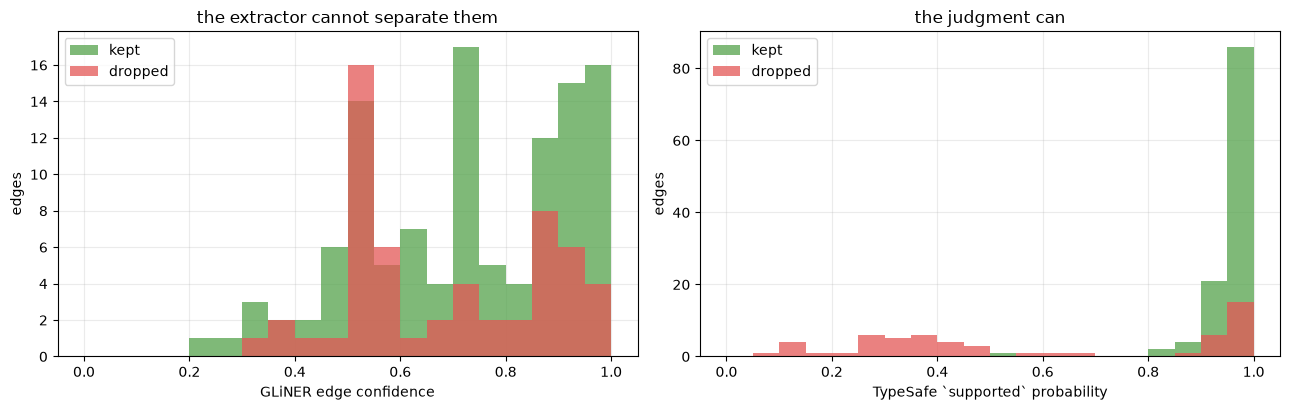

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (col, label) in zip(axes, [("gliner", "GLiNER edge confidence"),
                                   ("supported", "TypeSafe `supported` probability")]):
    for keep, colour, name in [(True, "#54A24B", "kept"), (False, "#E45756", "dropped")]:
        ax.hist(J[J["keep"] == keep][col], bins=20, range=(0, 1), alpha=0.75,
                color=colour, label=name)
    ax.set_xlabel(label); ax.set_ylabel("edges"); ax.legend(); ax.set_axisbelow(True)
    ax.grid(alpha=0.25)
axes[0].set_title("the extractor cannot separate them")
axes[1].set_title("the judgment can")
plt.tight_layout(); plt.show()

### 2.4 Does gating help? Score both against the gold triples

`GOLD_DOC_FACTS` is 47 hand-written triples: what a perfect extractor and resolver should recover. Scoring
is `kgx.evaluate.score_triples` with the repo's standard alias-tolerant policy, so this is comparable with
notebooks 01, 03 and 07.

The prediction is made twice from **one** extraction pass and **one** inference pass — ungated, and gated.
Nothing else changes.

In [12]:
from kgx.extract import DocGraph

KEEP = {(j.doc_id, j.head, j.relation, j.tail) for j in judgments if j.keep}

def gate(graphs, keep):
    """Rebuild the doc graphs with only the edges a judgment kept."""
    out = []
    for g in graphs:
        kept = [e for e in g.edges
                if (g.doc_id, g.mention(e.head).text, e.type, g.mention(e.tail).text) in keep]
        out.append(DocGraph(doc_id=g.doc_id, text=g.text, mentions=list(g.mentions),
                            edges=kept, feasible=g.feasible, meta=dict(g.meta)))
    return out

gated_graphs = gate(graphs, KEEP)
print(f"edges: {sum(len(g.edges) for g in graphs)} ungated -> "
      f"{sum(len(g.edges) for g in gated_graphs)} gated")

edges: 170 ungated -> 114 gated


In [13]:
resolver = kgx.EntityResolver().learn_aliases(d["text"] for d in DOCUMENTS)
resolution = resolver.resolve(mentions)

def triples_for(doc_graphs, **kw):
    kg = kgx.build_graph(doc_graphs, resolution, kgx.BUSINESS_NEWS)
    return kg, graph_triples(kg, **kw)

kg_ungated, tri_ungated = triples_for(graphs)
kg_gated,   tri_gated   = triples_for(gated_graphs)

scores = {
    "GLiNER2.5, ungated":        score_triples(tri_ungated, GOLD_DOC_FACTS, policy=MATCH,
                                               aliases=ALIAS_GROUPS),
    "+ TypeSafe assertion gate": score_triples(tri_gated, GOLD_DOC_FACTS, policy=MATCH,
                                               aliases=ALIAS_GROUPS),
}
display(comparison_table(scores))

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
+ TypeSafe assertion gate,normalised + aliases,47,47,19,0.404,0.404,0.404
"GLiNER2.5, ungated",normalised + aliases,68,47,19,0.279,0.404,0.330


A gate can only ever *remove* triples, so recall cannot rise and precision can. Whether that is a good
trade depends on what the graph is for — and the honest way to show it is not one row but the whole
frontier, which the next cell draws by sweeping the `supported` threshold. All of it comes from the same
single inference pass: **changing a threshold re-reads stored judgments, it does not re-ask the model.**

best F1 0.409 at supported >= 0.6, asserted only
(inference cost of this entire sweep: 0 new requests)


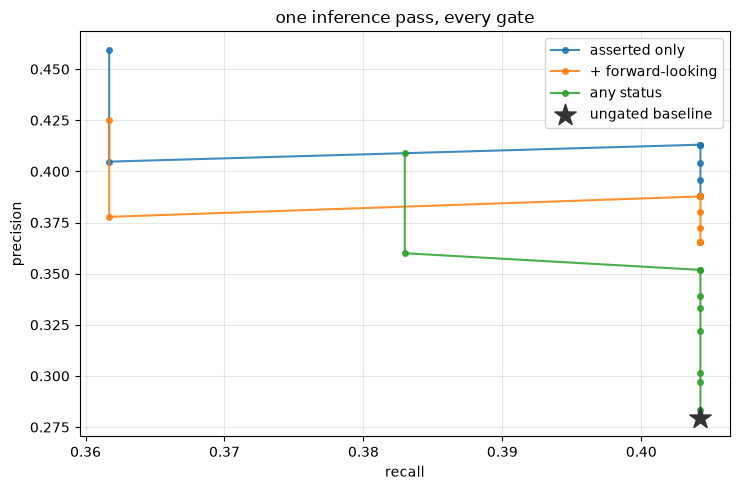

statuses,asserted only,+ forward-looking,any status
supported >=,,,
0.00,0.396,0.384,0.330
0.10,0.396,0.384,0.333
0.20,0.396,0.384,0.342
0.30,0.396,0.384,0.345
0.40,0.400,0.388,0.358
0.50,0.404,0.392,0.365
0.60,0.409,0.396,0.369
0.70,0.409,0.396,0.376
0.80,0.409,0.396,0.376


In [14]:
sweep = []
for tau in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    for statuses, label in [(kts.ASSERTED, "asserted only"),
                            (frozenset({"asserted", "forward_looking"}), "+ forward-looking"),
                            (frozenset(kts.ASSERTION_LEVELS), "any status")]:
        keep = {(j.doc_id, j.head, j.relation, j.tail) for j in judgments
                if j.supported >= tau and j.status in statuses}
        _, tri = triples_for(gate(graphs, keep))
        s = score_triples(tri, GOLD_DOC_FACTS, policy=MATCH, aliases=ALIAS_GROUPS)
        sweep.append({"supported >=": tau, "statuses": label, "triples": len(tri),
                      "precision": s.precision, "recall": s.recall, "f1": s.f1})

S = pd.DataFrame(sweep)
best = S.loc[S["f1"].idxmax()]
print(f"best F1 {best['f1']:.3f} at supported >= {best['supported >=']}, {best['statuses']}")
print(f"(inference cost of this entire sweep: {ts.n_calls} new requests)")

fig, ax = plt.subplots(figsize=(7.5, 5))
for label, grp in S.groupby("statuses", sort=False):
    ax.plot(grp["recall"], grp["precision"], "o-", label=label, alpha=0.85, markersize=4)
u = scores["GLiNER2.5, ungated"]
ax.scatter([u.recall], [u.precision], marker="*", s=260, color="#333", zorder=5,
           label="ungated baseline")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.grid(alpha=0.3)
ax.set_title("one inference pass, every gate")
ax.legend(); plt.tight_layout(); plt.show()

display(S.pivot_table(index="supported >=", columns="statuses", values="f1", sort=False).round(3))

---

## 3. Resolution — the review band, adjudicated

### 3.1 The baseline, and the number quoted beside it

`kgx.EntityResolver` is the repo's hand-rolled pipeline: normalise → block → score → cluster →
canonicalise. Scored B-cubed against the 13 gold alias groups, it lands where notebooks 01 and 05 say it
does — **precision 1.000, recall short of it.** Every point of headroom is in recall.

`pair_completeness` is the number to watch beside it: the fraction of gold-same pairs blocking ever
*proposed*. A pair blocking never generated cannot be adjudicated, only missed — which is the finding
notebook 05 lands on, that the wins come from candidate generation rather than from better scoring.

It is **not** an upper bound on B-cubed recall, and the two numbers below make that concrete by crossing.
Clustering is transitive: if `Northwind Logistics Inc.`–`Northwind Logistics` and
`Northwind Logistics`–`Northwind` are both candidates, the third pair is united without ever being
proposed. So pair completeness bounds what the *adjudicator* can see, not what the clustering can reach.

In [15]:
GOLD = {}
for canon, aliases in ALIAS_GROUPS.items():
    surfaces = {a.strip() for a in aliases}
    for m in mentions:
        if m.text.strip() in surfaces:
            GOLD[m.mention_id] = canon

base = kgx.bcubed(resolution.mention_to_canon, GOLD)
blocking = resolver.blocking_report(mentions, GOLD)

print(f"{len(resolution.entities)} canonical entities from {len(mentions)} mentions, "
      f"{len(GOLD)} gold-labelled")
print(f"B-cubed   precision {base['precision']:.4f}   recall {base['recall']:.4f}   "
      f"F1 {base['f1']:.4f}   (n={base['n']})")
print(f"blocking  pair completeness {blocking['pair_completeness']:.4f}  "
      f"({int(blocking['gold_pairs'])} gold pairs, {int(blocking['candidate_pairs'])} candidates "
      f"from {int(blocking['all_pairs'])} possible)")

109 canonical entities from 214 mentions, 77 gold-labelled
B-cubed   precision 1.0000   recall 0.8972   F1 0.9458   (n=77)
blocking  pair completeness 0.8791  (339 gold pairs, 1462 candidates from 22791 possible)


### 3.2 What is in the review band

`Resolution.review_band(low)` returns pairs blocking proposed and scoring placed **below the merge
threshold but above `low`** — too close to call. The repo's docstring calls this "the slot an LLM
adjudicator fills"; notebook 05 filled it with Claude.

It is not an arbitrary band. The README states the rule that puts these pairs there:

> *A prefix match is not an identity.* `Northwind` / `Northwind Logistics` should merge; `Apple` /
> `Apple Bank` should not, and the string evidence is identical.

The resolver therefore holds every bare prefix match back at 0.880, just under its 0.9 threshold. Which is
the correct thing for a string metric to do, and leaves a decision that needs world knowledge sitting in a
queue.

In [16]:
BAND_LOW = 0.70
band = resolution.review_band(low=BAND_LOW)
TEXT = {m.mention_id: m for m in mentions}

def gold_verdict(p):
    ga, gb = GOLD.get(p.a), GOLD.get(p.b)
    if ga is None or gb is None:
        return "unlabelled"
    return "same" if ga == gb else "different"

B = pd.DataFrame([{"a": TEXT[p.a].text, "b": TEXT[p.b].text, "type": p.type,
                   "resolver": round(p.score, 3), "block": p.block, "gold": gold_verdict(p)}
                  for p in band])
print(f"{len(band)} pairs in the band [{BAND_LOW}, {resolution.threshold})\n")
print(B["gold"].value_counts().to_string())
print()
display(B.drop_duplicates(subset=["a", "b", "type"]).head(20))

55 pairs in the band [0.7, 0.9)

gold
same          34
unlabelled    21



,a,b,type,resolver,block,gold
0,Northwind Logistics Inc.,Northwind,company,0.880,head,same
1,Northwind Logistics,Northwind,company,0.880,head,same
4,Northwind,Northwind Logistics,company,0.880,head,same
5,Northwind,Northwind Logistics Inc.,company,0.880,head,same
11,Halcyon Semiconductor Corporation,Halcyon,company,0.880,head,same
22,Halcyon Semiconductor,Halcyon,company,0.880,head,same
26,Halcyon,Halcyon Semiconductor,company,0.880,head,same
34,Adjusted operating margin,operating margin,financial_metric,0.844,tail,unlabelled
35,adjusted operating margin,operating margin,financial_metric,0.837,tail,unlabelled
36,gross margin,non-GAAP gross margin,financial_metric,0.835,tail,unlabelled


### 3.3 The question

This is TypeSafe's own
[entity-alignment cookbook](https://docs.typesafe.ai/cookbooks/entity_alignment.md), moved from beer
catalogues to company mentions. The shape it recommends is worth stating on its own, because it is not the
obvious one:

**one `Score` whose levels *are* the outcomes**, instead of a probability plus two fitted thresholds.

```
0  different entities          ->  leave unlinked
1  related, may be the same    ->  curator queue
2  the same entity             ->  merge
```

The decision rule is then `round(score)` — there is nothing to tune, and the middle level is not a hedge,
it is the review queue the repo already has a name for. Three diagnostic `Noul`s ride along in the same
request: they do not feed the decision, they make a disagreement with the resolver **attributable** rather
than mysterious.

The state sends each mention's **context window**, not just its surface string. That is the whole game:
`Apple` and `Apple Bank` are inseparable as strings and separable in context, and `kgx.extract.Mention`
already carries the window for exactly this reason.

In [17]:
show_questions(kts.pair_questions("company"))

{
  "link_state": {
    "type": "score",
    "criteria": [
      "They refer to two different real-world entities.",
      "They refer to closely related entities that may or may not be the same one.",
      "They refer to one and the same real-world entity."
    ],
    "instructions": "`mention_a` and `mention_b` are two mentions of a company, each quoted with the surrounding sentence it appeared in. How do they relate?"
  },
  "same_name": {
    "type": "noul",
    "instructions": "Ignoring abbreviations, legal suffixes, honorifics and possessives, do `mention_a.text` and `mention_b.text` name the same thing?"
  },
  "same_context": {
    "type": "noul",
    "instructions": "Do `mention_a.context` and `mention_b.context` describe the same entity doing the same kind of thing, rather than two different entities that happen to share part of a name?"
  },
  "abbreviation": {
    "type": "noul",
    "instructions": "Is one of `mention_a.text` and `mention_b.text` an abbreviation, acronym,

In [18]:
t0 = time.perf_counter()
before_calls, before_cached = ts.n_calls, ts.n_cached
verdicts = kts.adjudicate_pairs(ts, band, TEXT)
adj_s = time.perf_counter() - t0

V = pd.DataFrame([v.as_record() for v in verdicts])
V["gold"] = [gold_verdict(p) for p in band]

print(f"{len(verdicts)} pairs adjudicated in {adj_s:.1f}s "
      f"({ts.n_calls - before_calls} live, {ts.n_cached - before_cached} replayed)\n")
print(pd.crosstab(V["outcome"], V["gold"]).to_string())
display(V.sort_values("level", ascending=False).head(18))

55 pairs adjudicated in 0.0s (0 live, 55 replayed)

gold     same  unlabelled
outcome                  
merge      28          10
reject      0           3
review      6           8


,a,b,type,resolver,level,conf,same_name,same_context,abbrev,outcome,gold
25,Halcyon Semiconductor,Halcyon,company,0.880,1.99,0.99,0.87,0.96,0.93,merge,same
20,Halcyon Semiconductor Corporation,Halcyon,company,0.880,1.99,0.99,0.86,0.91,0.94,merge,same
21,Halcyon Semiconductor Corporation,Halcyon,company,0.880,1.98,0.96,0.71,0.86,0.90,merge,same
46,Telematics unit,Telematics,business_segment,0.734,1.98,0.96,0.86,0.78,0.79,merge,unlabelled
39,"Phoenix, Arizona",Phoenix,geography,0.778,1.97,0.96,0.83,0.92,0.85,merge,unlabelled
16,Halcyon Semiconductor Corporation,Halcyon,company,0.880,1.96,0.94,0.88,0.61,0.94,merge,same
17,Halcyon Semiconductor Corporation,Halcyon,company,0.880,1.96,0.93,0.85,0.61,0.94,merge,same
33,Halcyon Semiconductor,Halcyon,company,0.880,1.96,0.94,0.61,0.82,0.90,merge,same
3,Northwind Logistics Inc.,Northwind,company,0.880,1.96,0.94,0.81,0.76,0.93,merge,same
41,"Phoenix, Arizona",Phoenix,geography,0.755,1.95,0.93,0.86,0.75,0.84,merge,unlabelled


### 3.4 Apply the merges, and re-score

`apply_verdicts` folds accepted merges into the resolver's clustering by union-find and returns a fresh
`mention_id -> canon_id` map. It does not mutate the `Resolution`, so the before/after comparison stays
runnable in either order.

Transitivity is the point and the risk in the same mechanism: three pairwise merges can produce one cluster
that no single verdict proposed. `Resolution.oversized()` is the check, and it runs below.

In [19]:
merged = kts.apply_verdicts(resolution, verdicts)                          # merge only
merged_loose = kts.apply_verdicts(resolution, verdicts, accept=("merge", "review"))

rows = []
for name, mapping in [("kgx.EntityResolver", resolution.mention_to_canon),
                      ("+ TypeSafe (merge)", merged),
                      ("+ TypeSafe (merge + review)", merged_loose)]:
    b = kgx.bcubed(mapping, GOLD)
    rows.append({"resolver": name, "clusters": len(set(mapping.values())),
                 "precision": round(b["precision"], 4), "recall": round(b["recall"], 4),
                 "f1": round(b["f1"], 4)})
display(pd.DataFrame(rows).set_index("resolver"))
print(f"\nfor reference, blocking pair completeness: {blocking['pair_completeness']:.4f} "
      f"-- what the adjudicator could see, not a bound on the score above")

,clusters,precision,recall,f1
resolver,,,,
kgx.EntityResolver,109,1.0,0.8972,0.9458
+ TypeSafe (merge),104,1.0,0.8972,0.9458
+ TypeSafe (merge + review),100,1.0,0.8972,0.9458



for reference, blocking pair completeness: 0.8791 -- what the adjudicator could see, not a bound on the score above


**Zero movement.** Not a rounding artefact — precision, recall and F1 are identical to four places across
all three rows, while the clustering genuinely changed (109 → 104 → 100 clusters). So the next cell asks
the only question that matters: the adjudicator made merges, and none of them mattered. Which?

In [20]:
from collections import defaultdict
from itertools import combinations

by_gold = defaultdict(list)
for mid, g in GOLD.items():
    by_gold[g].append(mid)

proposed = {frozenset((p.a, p.b)) for p in resolution.pairs}
adjudicated = {frozenset((p.a, p.b)) for p in band}

split = []
for g, mids in by_gold.items():
    for a, b in combinations(sorted(mids), 2):
        if merged[a] != merged[b]:
            split.append({"gold": g, "a": TEXT[a].text, "b": TEXT[b].text,
                          "blocking proposed it": frozenset((a, b)) in proposed,
                          "adjudicator saw it": frozenset((a, b)) in adjudicated})
SPLIT = pd.DataFrame(split)

print(f"gold-same mention pairs still in different clusters after merging: {len(SPLIT)}")
if len(SPLIT):
    print(SPLIT.groupby(["blocking proposed it", "adjudicator saw it"]).size()
              .to_frame("pairs").to_string())
    display(SPLIT.drop_duplicates(subset=["a", "b"]).head(12))

applied = [v for v in verdicts if v.outcome == "merge"]
moved = [v for v in applied if GOLD.get(v.a) or GOLD.get(v.b)]
print(f"\nmerges applied: {len(applied)}")
print(f"  on gold-labelled mentions : {len(moved)}")
print(f"  already in the same cluster before adjudication: "
      f"{sum(1 for v in applied if resolution.mention_to_canon[v.a] == resolution.mention_to_canon[v.b])}")
print(f"  on mentions outside ALIAS_GROUPS entirely     : {len(applied) - len(moved)}")

gold-same mention pairs still in different clusters after merging: 41
                                         pairs
blocking proposed it adjudicator saw it       
False                False                  41


,gold,a,b,blocking proposed it,adjudicator saw it
0,Halcyon Semiconductor Corporation,Halcyon Semiconductor Corporation,HLCN,False,False
3,Halcyon Semiconductor Corporation,Halcyon Semiconductor,HLCN,False,False
6,Halcyon Semiconductor Corporation,HLCN,Halcyon Semiconductor Corporation,False,False
7,Halcyon Semiconductor Corporation,HLCN,Halcyon,False,False
9,Halcyon Semiconductor Corporation,HLCN,Halcyon Semiconductor,False,False
25,Halcyon Semiconductor Corporation,Halcyon,HLCN,False,False
33,Torrent Microsystems,Torrent Microsystems,Torrent Microsystems,False,False
37,Vantage Energy Partners,Vantage Energy Partners,Vantage Energy Partners,False,False



merges applied: 38
  on gold-labelled mentions : 28
  already in the same cluster before adjudication: 28
  on mentions outside ALIAS_GROUPS entirely     : 10


In [21]:
# What actually changed: clusters that grew, and any that grew too much.
from collections import defaultdict

after = defaultdict(list)
for mid, cid in merged.items():
    after[cid].append(mid)

changed = []
for cid, members in after.items():
    origins = {resolution.mention_to_canon[m] for m in members}
    if len(origins) > 1:
        changed.append({"merged cluster": cid, "mentions": len(members),
                        "was": len(origins),
                        "surfaces": ", ".join(sorted({TEXT[m].text for m in members}))[:96]})
display(pd.DataFrame(changed).sort_values("mentions", ascending=False))

oversized = [c for c, m in after.items() if len(m) > 15]
print(f"clusters over 15 mentions after merging: {len(oversized)}")
for c in oversized:
    print(f"  {c}: {len(after[c])} mentions, "
          f"{len(sorted({TEXT[m].text for m in after[c]}))} distinct surfaces")

,merged cluster,mentions,was,surfaces
3,geography:phoenix,7,2,"PHOENIX, Phoenix, Phoenix, Arizona"
0,sector:freight,6,2,"Freight, freight, freight brokerage"
1,business_segment:telematics,4,2,"Telematics, Telematics unit, telematics ..."
2,financial_metric:adjusted-operating-margin,3,2,"Adjusted operating margin, adjusted oper..."
4,financial_metric:gross-margin,2,2,"gross margin, non-GAAP gross margin"


clusters over 15 mentions after merging: 1
  company:northwind-logistics-inc: 19 mentions, 4 distinct surfaces


### 3.5 Why those pairs were never proposed

The pairs still split are not near-misses that scoring fumbled. Look at what they are: `HLCN` against every
spelling of Halcyon, and — stranger — `Torrent Microsystems` against **itself**.

Two identical strings in different clusters is not a string-similarity failure. It is a **type** failure.

In [22]:
by_surface = {}
for m in mentions:
    by_surface.setdefault(m.text.strip(), set()).add(m.type)

conflicted = {t: sorted(v) for t, v in by_surface.items() if len(v) > 1}
print("surfaces the extractor assigned more than one type:")
for t, types in conflicted.items():
    print(f"  {t!r}: {types}")

print("\nHLCN   ->", sorted({m.type for m in mentions if m.text.strip() == 'HLCN'}))
print("Halcyon* ->", sorted({m.type for m in mentions if 'Halcyon' in m.text}))
print("\nblocking is type-scoped, so a cross-type pair is never a candidate, "
      "whatever the strings say.")

surfaces the extractor assigned more than one type:
  'Torrent Microsystems': ['company', 'security']
  'Vantage Energy Partners': ['company', 'security']

HLCN   -> ['security']
Halcyon* -> ['company']

blocking is type-scoped, so a cross-type pair is never a candidate, whatever the strings say.


`HLCN` is typed **`security`** — a ticker symbol, which it literally is — and `Halcyon Semiconductor` is
typed **`company`**. Both are defensible readings of `(NASDAQ: HLCN)`. Blocking is type-scoped, so the pair
is never generated, and the resolver's scoring function never runs on the single most obvious merge in the
corpus.

The repo has already found this exact shape once, in notebook 09's gazetteer:

> *validate any type constraint you put on it: matching the extractor's type against the vocabulary's kind
> cost 20 points of coverage and prevented zero errors, because both sides reasonably disagreed about
> whether an airport is a place.*

Which makes a cheap, direct test available. `abbreviation` is one of the three diagnostic questions the
adjudicator already asks. **Hand it the pairs blocking refused to propose, and see.**

In [23]:
from kgx.resolve import ScoredPair

# Gold-same pairs blocking never proposed, deduplicated to one per surface+type
# combination so the same decision is not bought twice.
unproposed, seen = [], set()
for g, mids in by_gold.items():
    for a, b in combinations(sorted(mids), 2):
        if frozenset((a, b)) in proposed or merged[a] == merged[b]:
            continue
        ma, mb = TEXT[a], TEXT[b]
        key = (ma.text.strip(), ma.type, mb.text.strip(), mb.type)
        if key in seen:
            continue
        seen.add(key)
        label = ma.type if ma.type == mb.type else f"{ma.type} or {mb.type}"
        unproposed.append(ScoredPair(a=a, b=b, type=label, block="never proposed", score=0.0))

print(f"{len(unproposed)} distinct pairs blocking never proposed "
      f"({sum(1 for p in unproposed if ' or ' in p.type)} of them cross-type)")

cross = kts.adjudicate_pairs(ts, unproposed, TEXT)
C = pd.DataFrame([v.as_record() for v in cross])
print()
print(C["outcome"].value_counts().to_string())
display(C.sort_values("level", ascending=False).head(15))

8 distinct pairs blocking never proposed (8 of them cross-type)

outcome
merge     7
review    1


,a,b,type,resolver,level,conf,same_name,same_context,abbrev,outcome
6,Torrent Microsystems,Torrent Microsystems,security or company,0.0,2.00,0.99,0.98,0.96,0.03,merge
2,HLCN,Halcyon Semiconductor Corporation,security or company,0.0,1.99,0.99,0.62,0.75,0.98,merge
0,Halcyon Semiconductor Corporation,HLCN,company or security,0.0,1.88,0.81,0.62,0.52,0.94,merge
5,Halcyon,HLCN,company or security,0.0,1.88,0.81,0.71,0.78,0.94,merge
1,Halcyon Semiconductor,HLCN,company or security,0.0,1.86,0.78,0.57,0.76,0.94,merge
7,Vantage Energy Partners,Vantage Energy Partners,company or security,0.0,1.83,0.74,0.87,0.62,0.03,merge
4,HLCN,Halcyon Semiconductor,security or company,0.0,1.72,0.58,0.75,0.34,0.88,merge
3,HLCN,Halcyon,security or company,0.0,1.49,0.23,0.68,0.22,0.83,review


In [24]:
recovered = kts.apply_verdicts(resolution, list(verdicts) + list(cross))
rec = kgx.bcubed(recovered, GOLD)

display(pd.DataFrame([
    {"resolver": "kgx.EntityResolver", **{k: round(v, 4) for k, v in base.items() if k != "n"}},
    {"resolver": "+ TypeSafe on the review band",
     **{k: round(v, 4) for k, v in kgx.bcubed(merged, GOLD).items() if k != "n"}},
    {"resolver": "+ TypeSafe on pairs blocking refused",
     **{k: round(v, 4) for k, v in rec.items() if k != "n"}},
]).set_index("resolver"))

print(f"clusters: {len(set(resolution.mention_to_canon.values()))} -> "
      f"{len(set(recovered.values()))}")
bad = [v for v in cross if v.outcome == "merge"
       and GOLD.get(v.a) and GOLD.get(v.b) and GOLD[v.a] != GOLD[v.b]]
print(f"merges contradicting the gold labels: {len(bad)}")

,precision,recall,f1
resolver,,,
kgx.EntityResolver,1.0,0.8972,0.9458
+ TypeSafe on the review band,1.0,0.8972,0.9458
+ TypeSafe on pairs blocking refused,1.0,1.0000,1.0000


clusters: 109 -> 101
merges contradicting the gold labels: 0


### 3.6 Where the two disagree

The diagnostics earn their tokens here. Any pair where the resolver and the adjudicator disagree can be
attributed to something — a name that does not match on the surface, a context that does not agree, an
abbreviation the string metric could not expand — rather than being filed under "the model said so".

In [25]:
D = V.copy()
D["resolver_would"] = ["merge" if p.score >= resolution.threshold else "hold" for p in band]
disagree = D[((D["resolver_would"] == "hold") & (D["outcome"] == "merge")) |
             ((D["resolver_would"] == "merge") & (D["outcome"] != "merge"))]

print(f"{len(disagree)} disagreements of {len(D)} pairs "
      f"({len(disagree.drop_duplicates(subset=['a', 'b']))} distinct surface pairs)\n")
display(disagree.drop_duplicates(subset=["a", "b"])
                .sort_values("level", ascending=False)
                [["a", "b", "type", "resolver", "level", "conf",
                  "same_name", "same_context", "abbrev", "outcome", "gold"]].head(20))

wrong = V[((V["outcome"] == "merge") & (V["gold"] == "different"))]
print(f"\nmerges that contradict the gold labels: {len(wrong)}")
if len(wrong):
    display(wrong)

38 disagreements of 55 pairs (11 distinct surface pairs)



,a,b,type,resolver,level,conf,same_name,same_context,abbrev,outcome,gold
0,Northwind Logistics Inc.,Northwind,company,0.880,1.94,0.91,0.88,0.70,0.92,merge,same
11,Halcyon Semiconductor Corporation,Halcyon,company,0.880,1.94,0.90,0.92,0.61,0.94,merge,same
37,Telematics unit,Telematics,business_segment,0.803,1.94,0.91,0.90,0.89,0.70,merge,unlabelled
38,"Phoenix, Arizona",Phoenix,geography,0.786,1.93,0.90,0.85,0.75,0.84,merge,unlabelled
1,Northwind Logistics,Northwind,company,0.880,1.91,0.86,0.64,0.59,0.91,merge,same
22,Halcyon Semiconductor,Halcyon,company,0.880,1.88,0.82,0.83,0.66,0.91,merge,same
36,gross margin,non-GAAP gross margin,financial_metric,0.835,1.82,0.74,0.37,0.94,0.47,merge,unlabelled
26,Halcyon,Halcyon Semiconductor,company,0.880,1.77,0.66,0.80,0.62,0.81,merge,same
35,adjusted operating margin,operating margin,financial_metric,0.837,1.67,0.51,0.32,0.90,0.62,merge,unlabelled
6,Northwind,Northwind Logistics Inc.,company,0.880,1.54,0.31,0.67,0.47,0.77,merge,same



merges that contradict the gold labels: 0


---

## 4. The graph — judgments as data

Both stages above produce **typed values, not prose**, which means they can survive into the graph as
properties instead of being spent at the point of decision.

So build the graph **ungated**, on the adjudicated clustering, and put the judgment on the edge. The gate
from §2.4 does not disappear — it becomes a `WHERE` clause. Which is strictly more useful, because the
thing a gate throws away is also information: *"the corporate ontology says Northwind might acquire
Cascade, pending approval"* is a fact about the corpus, and a graph that silently dropped it cannot answer
a question about it.

- entities come from `merged`, the adjudicated clustering, via `build_graph(..., pin=)` — the same
  mechanism the gazetteer uses in notebook 09
- `kgx.graph.to_cypher` writes `confidence`, `support`, `docs` and `evidence`; a dozen lines add
  `assertion` and `supported` beside them
- re-filtering then costs nothing, which is the
  [composite-scoring pattern](https://docs.typesafe.ai/patterns/composite-scoring.md) and the reason to
  store raw judgments rather than a boolean

In [26]:
kg = kgx.build_graph(graphs, resolution, kgx.BUSINESS_NEWS, pin=merged)

print(kg.summary())
display(kg.frame(min_support=1).head(18))

KnowledgeGraph: 104 entities, 66 edges
  node labels: {'geography': 22, 'financial_metric': 17, 'product': 10, 'business_segment': 8, 'business_event': 7, 'security': 7, 'company': 7, 'person': 7, 'risk_factor': 6, 'regulator': 5, 'sector': 5, 'commodity': 3}
  edge types:  {'operates_in': 15, 'reports_metric': 12, 'officer_of': 7, 'produces': 7, 'partners_with': 6, 'competes_with': 4, 'participant_in': 4, 'subsidiary_of': 4, 'faces_risk': 4, 'acquires': 2, 'impacts': 1}


,head,head_type,relation,tail,tail_type,confidence,support,docs,derived
0,Vantage Energy Partners,company,produces,diesel,commodity,0.960,15,1,False
1,Northwind Logistics Inc,company,participant_in,transaction,business_event,0.863,8,1,False
2,Northwind Logistics Inc,company,reports_metric,revenue,financial_metric,0.870,7,2,False
3,Northwind Logistics Inc,company,partners_with,Cascade Freight Systems,company,0.582,6,1,False
4,Halcyon Semiconductor Corporation,company,operates_in,Germany,geography,0.977,5,1,False
5,Halcyon Semiconductor Corporation,company,faces_risk,fines,risk_factor,0.961,5,1,False
6,Northwind Logistics Inc,company,acquires,Cascade Freight Systems,company,0.943,5,3,False
7,Priya Raman,person,officer_of,Northwind Logistics Inc,company,0.927,5,4,False
8,Marcus Webb,person,officer_of,Northwind Logistics Inc,company,0.973,4,4,False
9,Northwind Logistics Inc,company,partners_with,Securities and Exchange Commission,regulator,0.903,4,1,False


In [27]:
import re

JUDGE = {(j.doc_id, j.head, j.relation, j.tail): j for j in judgments}

# Walk the document edges and carry each judgment up to the canonical triple its
# endpoints resolved to. Several sentences -- often in several documents -- can
# support one canonical edge, so they have to be aggregated, and the rule is the
# same one GraphEdge.confidence already uses: *an edge stated clearly once and
# hedged twice is still stated clearly once.*
#
# Which means ranking on assertion FIRST and support second. Ranking on support
# alone is a trap worth naming: `acquires(Northwind, Cascade)` is hedged in d01
# ("the proposed acquisition, if approved ...") at supported 0.99 and asserted in
# a later document at a lower one, so `max(supported)` labels the canonical edge
# hypothetical and silently disagrees with the gate in §2.4.
def rank(j):
    return (j.status in kts.ASSERTED, j.supported)

canon_judgment = {}
for g in graphs:
    for e in g.edges:
        head, tail = g.mention(e.head), g.mention(e.tail)
        j = JUDGE.get((g.doc_id, head.text, e.type, tail.text))
        if j is None:
            continue
        key = (merged[head.mention_id], e.type, merged[tail.mention_id])
        if key not in canon_judgment or rank(j) > rank(canon_judgment[key]):
            canon_judgment[key] = j

def judgment_cypher(kg, canon_judgment):
    """The statements that put the judgment onto the relationship."""
    out = []
    for e in kg.edges:
        j = canon_judgment.get((e.head, e.type, e.tail))
        if j is None:
            continue
        rel = re.sub(r"[^\w]", "_", e.type).upper()     # same transform as kgx.to_cypher
        out.append(
            f"MATCH (a {{canon_id: {json.dumps(e.head)}}})-[r:{rel}]->"
            f"(b {{canon_id: {json.dumps(e.tail)}}})\n"
            f"SET r.assertion = {json.dumps(j.status)}, r.supported = {j.supported:.4f};"
        )
    return out

statements = judgment_cypher(kg, canon_judgment)
cypher = (kgx.to_cypher(kg, min_support=1)
          + "\n\n// --- TypeSafe judgments ---\n" + "\n".join(statements))
(ROOT / "output" / "typesafe_business_news.cypher").write_text(cypher)

print(f"{len(kg.edges)} canonical edges, {len(canon_judgment)} carry a judgment; "
      f"{len(statements)} statements written")
print("\nassertion status across the canonical graph:")
print(pd.Series([j.status for j in canon_judgment.values()]).value_counts().to_string())
print()
print("\n".join(statements[:6]))
print(f"\n-> output/typesafe_business_news.cypher ({len(cypher.splitlines())} lines)")

66 canonical edges, 66 carry a judgment; 66 statements written

assertion status across the canonical graph:
asserted           48
negated            12
hypothetical        4
forward_looking     2

MATCH (a {canon_id: "company:northwind-logistics-inc"})-[r:ACQUIRES]->(b {canon_id: "company:cascade-freight-systems"})
SET r.assertion = "asserted", r.supported = 0.9800;
MATCH (a {canon_id: "company:cascade-freight-systems"})-[r:COMPETES_WITH]->(b {canon_id: "company:northwind-logistics-inc"})
SET r.assertion = "negated", r.supported = 0.3000;
MATCH (a {canon_id: "person:priya-raman"})-[r:OFFICER_OF]->(b {canon_id: "company:northwind-logistics-inc"})
SET r.assertion = "asserted", r.supported = 0.9900;
MATCH (a {canon_id: "person:marcus-webb"})-[r:OFFICER_OF]->(b {canon_id: "company:northwind-logistics-inc"})
SET r.assertion = "asserted", r.supported = 0.9800;
MATCH (a {canon_id: "company:cascade-freight-systems"})-[r:OPERATES_IN]->(b {canon_id: "geography:pacific-northwest"})
SET r.asserti

The check that this is the *same* filter, not a similar one: taking the annotated graph and applying the
gate as a predicate should reproduce a gated build exactly. It is worth running rather than assuming —
the first version of the aggregation above ranked on `supported` alone and quietly lost three edges here,
including the headline acquisition.

In [28]:
# Same clustering on both sides, so the only difference under test is *when* the
# gate is applied: before the graph is built, or as a predicate over it.
kg_final = kgx.build_graph(gated_graphs, resolution, kgx.BUSINESS_NEWS, pin=merged)
built_gated = set(kg_final.triples())

annotated = {(kg.name(e.head), e.type, kg.name(e.tail)) for e in kg.edges
             if (j := canon_judgment.get((e.head, e.type, e.tail))) is not None
             and j.supported >= 0.5 and j.status in kts.ASSERTED}

print(f"gated first, then built   : {len(built_gated)} triples")
print(f"built, then filtered      : {len(annotated)} triples")
print(f"identical: {annotated == built_gated}")
for label, diff in [("only in filtered", annotated - built_gated),
                    ("only in gated", built_gated - annotated)]:
    if diff:
        print(f"  {label}: {sorted(diff)[:5]}")

gated first, then built   : 46 triples
built, then filtered      : 46 triples
identical: True


Against a loaded graph, the same distinction in Cypher:

```cypher
// facts the corpus asserts
MATCH (a)-[r]->(b) WHERE r.assertion = 'asserted' AND r.supported >= 0.8
RETURN a.name, type(r), b.name, r.support

// and the thing a gate alone would have thrown away: what was floated and never asserted
MATCH (a)-[r]->(b) WHERE r.assertion IN ['hypothetical', 'forward_looking']
RETURN a.name, type(r), b.name, r.assertion, r.evidence
```

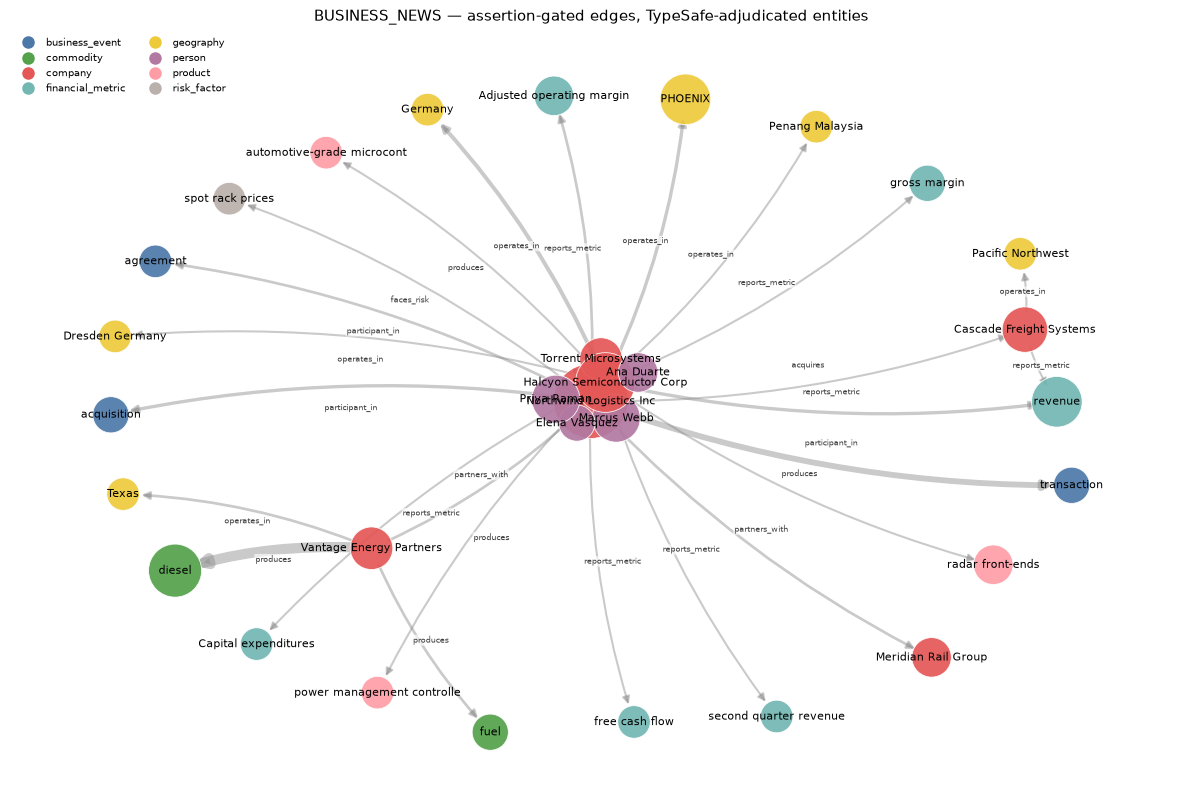

In [29]:
kgx.draw(kg_final, min_support=2, figsize=(15, 10),
         title="BUSINESS_NEWS — assertion-gated edges, TypeSafe-adjudicated entities")
plt.show()

---

## 5. What it cost

Tokens and wall time, separated into what **this run** billed and what the calls **were** when they were
first made — so a fully-cached re-run reports real latency instead of zeros. The same accounting
`kgx.llm.ClaudeCLI` does for the `claude` CLI.

In [30]:
stats = ts.stats()
display(pd.Series(stats).to_frame("value"))

n_req = stats["requests_live"] + stats["requests_cached"]
print(f"\n{stats['questions']} questions across {n_req} requests "
      f"({stats['questions_per_request']} per request)")
print(f"{stats['input_tokens_observed'] / max(1, stats['questions']):.0f} input tokens per question")
print(f"{stats['ms_per_request_observed']:.0f} ms per request (as observed, live or replayed)")
print(f"\nGLiNER2.5 extraction of the same corpus: {gliner_s:.1f}s, local, no key")

,value
requests_live,0.0
requests_cached,98.0
questions,627.0
questions_per_request,6.4
input_tokens_billed,0.0
output_tokens_billed,0.0
input_tokens_observed,122288.0
output_tokens_observed,18381.0
ms_spent,0.0
ms_per_request_observed,177.3



627 questions across 98 requests (6.4 per request)
195 input tokens per question
177 ms per request (as observed, live or replayed)

GLiNER2.5 extraction of the same corpus: 13.0s, local, no key


The comparison that matters is not TypeSafe against GLiNER — they are not doing the same job. It is the
**question batching**: every one of the edge-gating requests carried up to 24 questions over one shared
document, and the document's tokens were paid once per request rather than once per question. Run the same
work one question at a time and the input-token count is the thing that moves.

In [31]:
# The counterfactual, computed rather than asserted: what the same questions would
# have cost one per request. Only the *document* text is counted on both sides --
# the instructions cost the same either way, so they cancel.
import math

EDGES_PER_REQUEST = 24 // 2                     # what judge_edges(max_questions=24) chunks at
doc_tokens = {g.doc_id: len(g.text) / 4 for g in graphs}     # ~4 chars/token, order of magnitude

batched = sum(doc_tokens[g.doc_id] * math.ceil(len([e for e in g.edges if not e.derived])
                                               / EDGES_PER_REQUEST)
              for g in graphs)
unbatched = 2 * sum(doc_tokens[j.doc_id] for j in judgments)   # 2 questions, 1 request each

print(f"{2 * len(judgments)} edge questions over {len(graphs)} documents")
print(f"  batched, {EDGES_PER_REQUEST} edges per request:  ~{batched:>9,.0f} "
      f"input tokens of document text")
print(f"  one question per request:        ~{unbatched:>9,.0f}")
print(f"  ratio:                            {unbatched / max(1, batched):>9.1f}x")
print(f"\nmeasured input tokens, every request in this notebook: "
      f"{stats['input_tokens_observed']:,}")

340 edge questions over 10 documents
  batched, 12 edges per request:  ~    6,818 input tokens of document text
  one question per request:        ~  128,312
  ratio:                                 18.8x

measured input tokens, every request in this notebook: 122,288


---

## 6. Findings

*Measured on this repo's corpus, not asserted. Every number above is reproducible from the cached
responses in `output/typesafe_cache/`.*

In [32]:
print("=" * 78)
print("SUMMARY".center(78))
print("=" * 78)
print(f"corpus                   {len(DOCUMENTS)} documents, {len(mentions)} mentions, "
      f"{len(edges)} edges")
print()
print("EXTRACTION")
print(f"  modality traps caught  {caught}/{len(MODALITY_TRAPS)}")
print(f"  controls preserved     {int(controls['asserted'].sum())}/{len(controls)}")
print(f"  edges kept by gate     {int(J['keep'].sum())}/{len(J)}")
for name, s in scores.items():
    print(f"  {name:<22} P {s.precision:.3f}  R {s.recall:.3f}  F1 {s.f1:.3f}")
print()
print("RESOLUTION")
print(f"  baseline               P {base['precision']:.4f}  R {base['recall']:.4f}  "
      f"F1 {base['f1']:.4f}")
_m = kgx.bcubed(merged, GOLD)
print(f"  + TypeSafe             P {_m['precision']:.4f}  R {_m['recall']:.4f}  "
      f"F1 {_m['f1']:.4f}")
_r = kgx.bcubed(recovered, GOLD)
print(f"  + cross-type recovery  P {_r['precision']:.4f}  R {_r['recall']:.4f}  "
      f"F1 {_r['f1']:.4f}")
print(f"  blocking proposed      {blocking['pair_completeness']:.4f} of gold-same pairs")
print()
print("COST")
print(f"  requests               {stats['requests_live']} live, {stats['requests_cached']} replayed")
print(f"  questions              {stats['questions']} "
      f"({stats['questions_per_request']} per request)")
print(f"  input tokens observed  {stats['input_tokens_observed']:,}")
print("=" * 78)

                                   SUMMARY                                    
corpus                   10 documents, 214 mentions, 170 edges

EXTRACTION
  modality traps caught  8/11
  controls preserved     5/5
  edges kept by gate     114/170
  GLiNER2.5, ungated     P 0.279  R 0.404  F1 0.330
  + TypeSafe assertion gate P 0.404  R 0.404  F1 0.404

RESOLUTION
  baseline               P 1.0000  R 0.8972  F1 0.9458
  + TypeSafe             P 1.0000  R 0.8972  F1 0.9458
  + cross-type recovery  P 1.0000  R 1.0000  F1 1.0000
  blocking proposed      0.8791 of gold-same pairs

COST
  requests               0 live, 98 replayed
  questions              627 (6.4 per request)
  input tokens observed  122,288


### The assertion gate is the win, and it costs no recall

Gating on `supported >= 0.5 and status == 'asserted'` drops **56 of 170 edges** and takes triple precision
from **0.279 to 0.404** — with **recall unchanged at 0.404**. Not approximately: identical. Of the 56 edges
removed, not one was a gold triple.

The two failure columns say why that is possible. 31 of the 56 were edges the document never connected at
all; 25 were edges it connected and then hedged or denied. Both are invisible to a span model for the same
reason — **span confidence is about the decoding, not about the claim** — and the §2.3 histograms are the
compact version: GLiNER's own confidence does not separate kept from dropped, and `supported` does.

### A `Noul` that hides a second reading resolves it silently

The `factual` Noul caught **8 of 11** planted modality traps. The `Choice` over four statuses called all
eleven non-asserted, at mean confidence 0.78 on exactly the three the Noul let through.

Every miss is a **denial** — *"Management has no plans to divest…"*, *"the company said it has no plans…"*
— where the sentence states a perfectly true fact about an intention *not* to act. My question ("can the
main claim be recorded as a fact that currently holds?") has two readings for a denial, and the model picked
the other one. It came back at 0.66, 0.71 and 0.74: **not** at 0.5.

That is the part worth carrying away. A Noul near 0.5 means *equally likely yes or no*, so ambiguity in the
**question** does not surface as an uncertain answer — it surfaces as a confident answer to the reading you
did not mean. Naming `negated` as its own outcome in a `Choice` got the same model right on the same
sentences. **Keep the distinction in the answer type rather than folding it into a probability.**

### Controls are what make "caught 8 of 11" mean anything

Traps land at mean `factual` 0.266, controls at 0.858, ranges not overlapping (traps max 0.740, controls min
0.810). Without the control group a detector that answers *not factual* to everything scores 11/11.

### A perfect judge on the wrong queue is worth exactly nothing

Adjudicating the review band made **28 merges, every one correct, none contradicting the gold labels** — and
moved B-cubed by **zero to four decimal places** (P 1.0000, R 0.8972, F1 0.9458 before and after), while the
clustering genuinely changed from 109 to 104 clusters.

The §3.4 diagnostic gives the reason, and it is two things stacked. All 28 gold-labelled merges were **already
in one cluster by transitivity** before the adjudicator was asked. The 10 merges that did change clusters —
`Phoenix, Arizona`/`Phoenix`, `Telematics unit`/`Telematics`, `adjusted operating margin`/`operating margin` —
are on mentions **outside `ALIAS_GROUPS`**, which B-cubed cannot see.

This sharpens notebook 05's conclusion rather than repeating it. There, the wins came from candidate
generation rather than scoring. Here the judge scored *perfectly* and still bought nothing, because every
pair it was permitted to see was either redundant or unlabelled.

### The missing pairs were a type disagreement, not a string-similarity failure

41 gold-same pairs were still split, and **none of them had ever been proposed**. Their content is the
diagnosis: `HLCN` against every spelling of Halcyon, and `Torrent Microsystems` against **itself**.

Two identical strings in different clusters is not a scoring problem. The extractor types `HLCN` as
**`security`** — a ticker symbol, which it is — and `Halcyon Semiconductor` as **`company`**. It types the
string `Torrent Microsystems` as `company` in one document and `security` in another. Blocking is
type-scoped, so none of these pairs is ever a candidate, whatever the strings say, and the scoring function
never runs on the most obvious merge in the corpus.

This is notebook 09's gazetteer finding in a second location: *both sides reasonably disagreed about whether
an airport is a place.* Here they reasonably disagree about whether a ticker is a company or an instrument.
**A type constraint anywhere in candidate generation needs its cost measured, not assumed.**

### Handed the pairs blocking refused, the same judge reaches B-cubed 1.000

**8 requests.** 7 merges, 1 review, 0 contradicting the gold labels, and B-cubed F1 **0.9458 → 1.0000** at
precision 1.0000 — which is where notebook 05's best configurations (Splink, and Claude adjudication) also
land, reached from the opposite direction and with a diagnosis attached.

The diagnostic Nouls are what make it legible rather than lucky:

| pair | `same_name` | `abbrev` | |
|---|---|---|---|
| `Torrent Microsystems` / `Torrent Microsystems` | 0.98 | 0.03 | identical strings, correctly *not* an abbreviation |
| `HLCN` / `Halcyon Semiconductor Corporation` | 0.62 | 0.98 | the names do not match; the abbreviation carries it |

Two pairs needing merging for two unrelated reasons, and the raw judgments say which. The one `review`
outcome — `HLCN`/`Halcyon` at level 1.49, just under the boundary, `same_context` 0.22 — is the adjudicator
hedging on the least contextual pair, and transitivity recovers it anyway through the others.

### `pair_completeness` is not a ceiling on B-cubed recall

0.8791 against a baseline recall of 0.8972, and a recovered recall of 1.0000. The two get quoted together as
if the first bounded the second. It does not, because clustering is transitive and unites pairs blocking
never proposed. What it bounds is **what an adjudicator can be asked about** — which is the real constraint,
and precisely the one the review band ran into.

### Aggregating a judgment onto a canonical edge must rank on assertion, not support

The first version of §4 kept the highest-`supported` judgment per canonical edge and lost three edges,
including the headline acquisition. `acquires(Northwind, Cascade)` is hedged in d01 — *"the proposed
acquisition, if approved by the Surface Transportation Board"* — at `supported` 0.99, and asserted in a later
document at a lower one, so ranking on support alone picks the hedge.

The repo already had the right rule written down for a different field: *an edge stated clearly once and
hedged twice is still stated clearly once.* The §4 equivalence check is three lines and is the only reason
this was caught instead of shipped.

### Batching is worth ~19x on input tokens, and it is a design decision rather than a flag

627 questions in 98 requests at 180 ms each. Edge gating alone was 340 questions in 35 requests, because one
request carries up to a dozen edges over one shared document. One question per request would re-send each
document 34 times: ~128k tokens of document text against ~6.8k, a **18.8x** difference on that component.

That saving comes from what goes in the state, not from a batch endpoint. It also constrains how the
questions are written: every question in a request sees the same state and question ids are never sent to
the model, so each question has to name its own edge in its instructions.

### Where this sits next to the other two extractors

Not a replacement for either. GLiNER2.5 produced the 170 candidate edges in ~13 s on a CPU with no key, and
System One cannot do that — it has no spans and nothing to anchor. What it did was answer 627 questions
about those candidates that neither a span model nor a threshold could answer, in typed form, at about a
fifth of a second each.

**Candidate generation and judgment are different jobs.** Both findings above are the same shape from
opposite ends: the gate worked because the extractor had already produced the candidates, and the
adjudicator was useless until something produced the candidates it needed. Extract locally and
exhaustively, judge selectively, and keep the judgments as data.